# 🎬 Netflix Content Strategy Analysis

## 📌 Objective
Analyze Netflix dataset to uncover content trends and generate business insights.

## 🛠 Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## 📊 Dataset Source
Netflix Movies & TV Shows Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("netflix_titles.csv")
print("Dataset Loaded successfully:")
print("First 5-rows:")
df.head()

Dataset Loaded successfully:
First 5-rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


📌 The dataset contains information about movies and TV shows available on Netflix.

In [12]:
print("Last 5-rows:")
df.tail()

Last 5-rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


📌 Observations:
- Dataset contains missing values
- Multiple categorical features

In [8]:
df = df.copy()

df.dropna(subset=['country', 'date_added'], inplace=True)
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df.dropna(subset=['date_added'], inplace=True)

df['year_added'] = df['date_added'].dt.year

📌 Cleaned missing values and converted date columns for analysis.

In [9]:
df['type'].value_counts()

type
Movie      5691
TV Show    2276
Name: count, dtype: int64

In [17]:
# Recent vs old content
recent = df[df['release_year'] > 2015]
old = df[df['release_year'] <= 2015]

print("Recent Content:", len(recent))
print("Old Content:", len(old))

Recent Content: 4988
Old Content: 2979


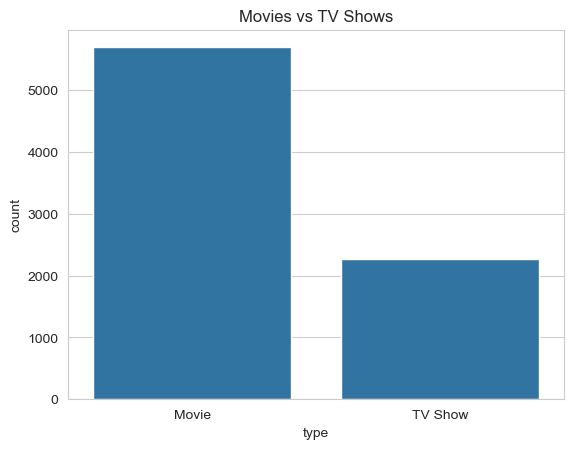

In [10]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

📌 Insight:
Movies dominate Netflix content compared to TV Shows.

In [11]:
df['country'].value_counts().head(10)

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

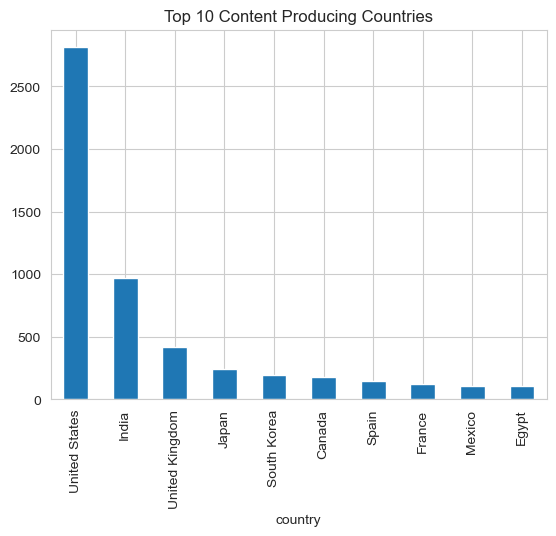

In [12]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.show()

📌 Insight:
USA is the leading content producer on Netflix.

In [13]:
df['year_added'].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      79
2016     410
2017    1123
2018    1530
2019    1858
2020    1771
2021    1140
Name: count, dtype: int64

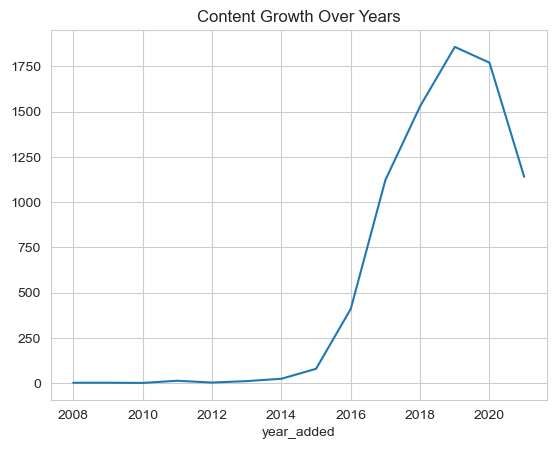

In [14]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Growth Over Years")
plt.show()

📌 Insight:
Content production increased significantly after 2015. 

In [15]:
df['listed_in'].str.split(',').explode().value_counts().head(10)

listed_in
 International Movies     2429
Dramas                    1528
Comedies                  1148
Action & Adventure         817
 Dramas                    789
Documentaries              759
 Independent Movies        725
International TV Shows     614
 TV Dramas                 597
 Romantic Movies           585
Name: count, dtype: int64

📌 Insight:
Drama and International content are among the most popular genres.

## 🔍 Key Insights

- Movies dominate over TV Shows
- USA produces the highest content
- Rapid growth observed after 2015
- Drama & International genres are most popular

## 💡 Business Recommendations

- Increase investment in TV Shows to balance content
- Expand production in emerging markets like India
- Focus on high-demand genres such as Drama

## ✅ Conclusion

This project demonstrates how data analysis can help understand content trends and support business decision-making.

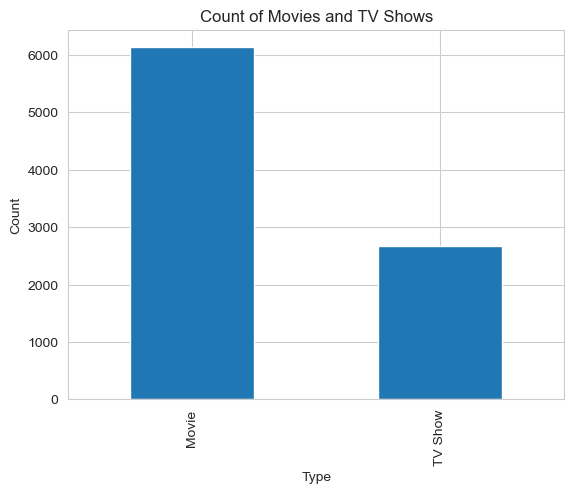

In [25]:
df["type"].value_counts().plot(kind="bar")
plt.title("Count of Movies and TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Index(['release_year'], dtype='object')


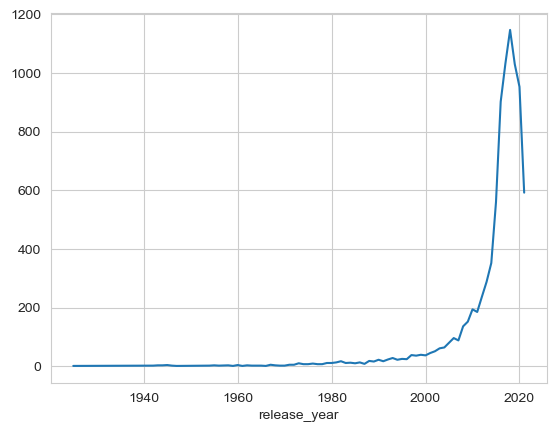

In [23]:
print(df.select_dtypes(include='number').columns)
df["release_year"].value_counts().sort_index().plot()
plt.show()